# Consistency Trajectory Models (CTM)

[![arXiv](https://img.shields.io/badge/arXiv-2310.02279-<COLOR>.svg)](https://arxiv.org/abs/2310.02279) [![GitHub Repo stars](https://img.shields.io/github/stars/sony/ctm?style=social) ](https://github.com/sony/ctm)

## 📖 Introduction

[A Consistency Trajectory Model (CTM)](https://consistencytrajectorymodel.github.io/CTM/) is a novel generative model that generalizes existing approaches like [Consistency Models](https://github.com/openai/consistency_models) and score-based diffusion models. It trains a single neural network to learn the entire trajectory of the Probability Flow Ordinary Differential Equation (ODE) in a diffusion process. This allows the model to output both scores (gradients of log-density) and enable movement between any points along the ODE solution curve in a single forward pass. By learning the full ODE trajectory, CTM offers fast, high-quality, and flexible sampling, overcoming limitations of previous approaches. The integration of GAN loss for performance enhancement and the introduction of γ-sampling for controlling stochasticity and semantic preservation are particularly noteworthy contributions.

<img src="assets/Picture3.png" alt="CTM" width="300" height="200">

### Key Idea

_Learn a model that directly parameterizes the entire probability flow ODE trajectory of diffusion models, enabling efficient sampling at arbitrary noise levels while preserving trajectory consistency. Essentially, CTM learns to represent the entire trajectory of the diffusion process, allowing for flexible and efficient sampling and generation._

### Definition of Consistency Trajectory Models (CTM)

CTM estimates the "anytime-to-anytime jump" along the PF ODE, meaning it can predict both infinitesimally small jumps (related to the score function) and long jumps (the integral over any time horizon). This provides increased flexibility during inference.

The true solution of the PF ODE from initial time $t$ to final time $s \leq t $ is defined as:

$G(x_t, t, s) := x_t + \int_{t}^{s} \frac{x_u - E[x|x_u]}{u} \, du $

The trajectory function of models:
- teacher trajectory:= $G_{sg}(\theta) (G_{sg}(\theta)(TeacherSolver(x_t,t,u),u,s),s,0)$
- student trajectory:= $G_{sg}(\theta) (G_{sg}(\theta)((x_t,t,s),s,0))$

### Key features and Contributions

- High-quality and fast sampling (single step or with a few steps)
- Flexible Sampling Schemes (γ-sampling) - Controllable Semantic Information in Generation (inpainting)
- Clear Trade-off between Speed and Quality
- Student model beats teacher model

<img src="assets/ctm_gamma.svg" alt="γ-sampling" width=600 height=300> 
<img src="assets/Picture4.png" alt="CTM" width="700" height=600">


## Training Methodology:

![CTM Training](assets/ctm_model.svg)

CTMs (the "student model") are typically trained by distilling knowledge from a pre-trained diffusion model (the "teacher model").

- The CTM is trained to replicate the trajectory of the teacher model's ODE solution
- The training involves defining an initial state (x_t), a start time (t), and an end time (s). An intermediate time (u) is used to split the teacher's trajectory.
- Knowledge Distillation: TThe model then learns to map from x_t to x_s directly, while also ensuring consistency by comparing this direct path to a path that goes from x_t to x_u using the teacher model and then from x_u to x_s using the CTM. 
- Consistency Loss: The CTM aims to make the point reached by applying only the CTM from t to s consistent with the point reached by applying the teacher from t to u and then the CTM from u to s. "CTM tries to match these two points."
- Perceptual Alignment: To improve the perceived quality of generations, the trajectory is also extended back to time 0 (the clean image).
- GAN Loss for Quality Improvement ("Student Beats Teacher"): CTM incorporates a GAN loss by directly comparing the output of the CTM at time 0 (x_student) with the true data (x_true). This allows the CTM's performance to exceed that of the teacher model, overcoming the limitations of purely distilling the teacher's knowledge which may have inherent errors. 

### γ-sampling in CTMs
γ-sampling is a new sampling method enabled by CTM's knowledge of the entire solution trajectory. γ is a hyperparameter that allows users to adjust the stochasticity of the sampling process. 

![CTM](assets/cat.png)

- When γ=1, the sampling is fully stochastic and similar to baseline methods. 
- When γ=0, the sampling is deterministic and unique to CTM. 

By setting γ to values between 0 and 1, users can introduce a desired level of stochasticity. This flexibility allows for controlling the degree to which the generated image retains semantic information from the initial state, making it useful for tasks like inpainting where semantic preservation is important, or for generating diverse images where meaning change is desired.

### Advantages over prior Distillation models

- More efficient learning of the entire probability flow trajectory
- Better preservation of trajectory consistency
- Higher Single-Step Performance
- More flexible control over the generation process
- Enhanced distillation of diffusion model knowledge

## Cross domain application of CTM

Consistency Trajectory Models provide a powerful framework for generative modeling across various domains. While we've explored the theoretical foundations and applications of CTM in image domain, the concept generalizes beyond image domain, like audio. For example - SoundCTM.

Sound generation represents an ideal application domain for CTM's unique capabilities. The temporal nature of audio, with its complex frequency relationships and phase coherence requirements, benefits tremendously from CTM's trajectory-based approach. 

#### SoundCTM resources

- https://arxiv.org/pdf/2405.18503
- https://github.com/sony/soundctm


## CTM - Author's words:
[![Youtube](https://i.ytimg.com/vi/Bp2t8IFmDGU/hq720.jpg?sqp=-oaymwEnCNAFEJQDSFryq4qpAxkIARUAAIhCGAHYAQHiAQoIGBACGAY4AUAB&rs=AOn4CLCuGZOY3BOVZAiQAbZT6KzU2nZQ3A)](https://www.youtube.com/watch?v=Bp2t8IFmDGU&pp=ygVMQ1RNOiBBZHZhbmNlZCBTaW5nbGUtU3RlcCBESWZmdXNpb24gTW9kZWwgZm9yIEZhc3QgYW5kIEhpZ2gtUXVhbGl0eSBTYW1wbGluZw%3D%3D)


### References

[1] Yang, Y., et al. (2023). Consistency Trajectory Models: Learning Probability Flow ODE Trajectory of Diffusion. arXiv.org. https://arxiv.org/abs/2310.02279

[2] Song, Y., Dhariwal, P., Chen, M., & Sutskever, I. (2023). Consistency models. arXiv.org. https://arxiv.org/abs/2303.01469

[3] Karras, T., Aittala, M., Aila, T., & Laine, S. (2022). Elucidating the design space of diffusion-based Generative Models. arXiv.org. https://arxiv.org/abs/2206.00364

## 🛠️ Setup

### Imports

In [1]:
import argparse
import torch.distributed as dist
import copy
import cm.enc_dec_lib as enc_dec_lib
import torch as th
import math
import random

from PIL import Image
import blobfile as bf

import numpy as np
from torch.utils.data import DataLoader, Dataset
import os

## 🧠  Implementation

### Download and extract the dataset

In [13]:
!gdown https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz && tar -xf cifar-10-python.tar.gz

Downloading...
From: https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
To: /workspace/cifar-10-python.tar.gz
100%|████████████████████████████████████████| 170M/170M [02:30<00:00, 1.13MB/s]


### Unpickle and save the dataset

In [16]:
import pickle
import numpy as np
import os
from PIL import Image

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

def save_cifar10_as_images(cifar_dir, output_dir):
    # Load class names
    meta = unpickle(os.path.join(cifar_dir, 'batches.meta'))
    class_names = [label.decode('utf-8') for label in meta[b'label_names']]
    
    # Create directories for each class
    for class_name in class_names:
        os.makedirs(os.path.join(output_dir, class_name), exist_ok=True)
    
    # Process training data
    for batch_id in range(1, 6):
        batch_file = os.path.join(cifar_dir, f'data_batch_{batch_id}')
        batch_data = unpickle(batch_file)
        images = batch_data[b'data']
        labels = batch_data[b'labels']
        
        for i, (image, label) in enumerate(zip(images, labels)):
            # Reshape and convert to RGB image
            image = image.reshape(3, 32, 32).transpose(1, 2, 0)
            img = Image.fromarray(image)
            # Save image
            img_path = os.path.join(output_dir, class_names[label], f'train_batch{batch_id}_{i}.png')
            img.save(img_path)
    
    # Process test data
    test_batch = unpickle(os.path.join(cifar_dir, 'test_batch'))
    test_images = test_batch[b'data']
    test_labels = test_batch[b'labels']
    
    for i, (image, label) in enumerate(zip(test_images, test_labels)):
        # Reshape and convert to RGB image
        image = image.reshape(3, 32, 32).transpose(1, 2, 0)
        img = Image.fromarray(image)
        # Save image
        img_path = os.path.join(output_dir, class_names[label], f'test_{i}.png')
        img.save(img_path)

# Usage
cifar_dir = 'cifar-10-batches-py'  # Path to your extracted CIFAR-10 directory
output_dir = 'cifar10_images'      # Where to save the images in folder structure
save_cifar10_as_images(cifar_dir, output_dir)

#### DataModule

In [2]:
def load_data(*,args,data_dir,batch_size,image_size,data_name='cifar10',train_classes=None,class_cond=False,deterministic=False,random_crop=False,
    random_flip=True,num_workers=32,type='jpeg',flip_ratio=0.5,):
    if not data_dir:
        raise ValueError("unspecified data directory")
    if train_classes == 281:
        data_dir = os.path.join(data_dir, 'n02123045')
        all_files = _list_image_files_recursively(data_dir, type=type)
    elif train_classes == -2:
        class_names = {'n01440764': 0, 'n01443537': 1, 'n01518878': 9, 'n01531178': 11, 'n01632777': 29, 'n01644373': 31,
                   'n01664065': 33, 'n01729977': 55, 'n01774750': 76, 'n01819313': 89, 'n01820546': 90, 'n02007558': 130,
                   'n02099601': 207, 'n02110185': 250, 'n02120079': 279, 'n02123045': 281, 'n02129165': 291, 'n02279972': 323,
                   'n02504458': 386, 'n02509815': 387, 'n02510455': 388, 'n02782093': 417, 'n03388043': 562, 'n03617480': 614,
                   'n04069434': 759, 'n04201297': 789, 'n04243546': 800, 'n04266014': 812, 'n04392985': 848, 'n07697313': 933,
                   'n09256479': 973, 'n09472597': 980}
        all_files = []
        classes = []
        for cl in list(class_names.keys()):
            data_dir_ = os.path.join(data_dir, cl)
            temp_files = _list_image_files_recursively(data_dir_, type=type)
            all_files.extend(temp_files)
            classes.extend([class_names[cl] for _ in temp_files])
    else:
        all_files = _list_image_files_recursively(data_dir, type=type)
        classes = None
    if class_cond:
        # Assume classes are the first part of the filename,
        # before an underscore.
        if train_classes == 281:
            classes = [281 for _ in all_files]
        if train_classes not in [281, -2]:
            if args.data_name.lower() == 'cifar10':
                classes = [int(path.split('/')[-2]) for path in all_files]
            else:
                class_names = [bf.basename(path).split("_")[0] for path in all_files]
                sorted_classes = {x: i for i, x in enumerate(sorted(set(class_names)))}
                classes = [sorted_classes[x] for x in class_names]

    import torch.distributed as dist
    dataset = ImageDataset(
        image_size,
        all_files,
        classes=classes,
        shard=dist.get_rank(),
        num_shards=dist.get_world_size(),
        random_crop=random_crop,
        random_flip=random_flip,
        data_name=data_name,
        type=type,
        flip_ratio=flip_ratio,
    )
    if deterministic:
        loader = DataLoader(
            dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False
        )
    else:
        loader = DataLoader(
            dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True
        )
    while True:
        yield from loader


def _list_image_files_recursively(data_dir, type='jpeg'):
    results = []
    for entry in sorted(bf.listdir(data_dir)):
        full_path = bf.join(data_dir, entry)
        ext = entry.split(".")[-1]
        if "." in entry and ext.lower() in ["npy", "jpg", "jpeg", "png", "gif"]:
            results.append(full_path)
        elif bf.isdir(full_path):
            results.extend(_list_image_files_recursively(full_path))
    return results


class ImageDataset(Dataset):
    def __init__(self, resolution,image_paths,classes=None,shard=0,num_shards=1,random_crop=False,random_flip=True,data_name='cifar10',type='jpeg',
    flip_ratio=0.5,):
        super().__init__()
        self.resolution = resolution
        self.local_images = image_paths[shard:][::num_shards]
        print(f"Total number of data: {len(image_paths)}, data for {shard}/{num_shards} device: {len(self.local_images)}")
        self.local_classes = None if classes is None else classes[shard:][::num_shards]
        self.random_crop = random_crop
        self.random_flip = random_flip
        self.data_name = data_name
        self.type = type
        self.flip_ratio = flip_ratio

    def __len__(self):
        return len(self.local_images)

    def __getitem__(self, idx):
        path = self.local_images[idx]
        if self.type == 'npy':
            data = np.load(path)
            out_dict = {}
            if self.local_classes is not None:
                out_dict["y"] = np.array(self.local_classes[idx], dtype=np.int64)
            return data, out_dict
        else:
            with bf.BlobFile(path, "rb") as f:
                pil_image = Image.open(f)
                pil_image.load()
            pil_image = pil_image.convert("RGB")

            if self.random_crop:
                arr = random_crop_arr(pil_image, self.resolution)
            else:
                arr = center_crop_arr(pil_image, self.resolution)

            if self.random_flip and random.random() < self.flip_ratio:
                arr = arr[:, ::-1]

            arr = arr.astype(np.float32) / 127.5 - 1

            out_dict = {}
            if self.local_classes is not None:
                out_dict["y"] = np.array(self.local_classes[idx], dtype=np.int64)
            return np.transpose(arr, [2, 0, 1]), out_dict


def center_crop_arr(pil_image, image_size, data_name='cifar10'):
    # We are not on a new enough PIL to support the `reducing_gap`
    # argument, which uses BOX downsampling at powers of two first.
    # Thus, we do it by hand to improve downsample quality.
    if data_name in ['church']:
        img = np.array(pil_image).astype(np.uint8)
        crop = min(img.shape[0], img.shape[1])
        h, w, = img.shape[0], img.shape[1]
        img = img[(h - crop) // 2:(h + crop) // 2,
              (w - crop) // 2:(w + crop) // 2]

        image = Image.fromarray(img)
        if image_size is not None:
            image = image.resize((image_size, image_size), resample='bicubic')
        return image
    else:
        while min(*pil_image.size) >= 2 * image_size:
            pil_image = pil_image.resize(
                tuple(x // 2 for x in pil_image.size), resample=Image.BOX
            )
        scale = image_size / min(*pil_image.size)
        pil_image = pil_image.resize(
            tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC
        )
        arr = np.array(pil_image)
        crop_y = (arr.shape[0] - image_size) // 2
        crop_x = (arr.shape[1] - image_size) // 2
        return arr[crop_y : crop_y + image_size, crop_x : crop_x + image_size]


def random_crop_arr(pil_image, image_size, min_crop_frac=0.8, max_crop_frac=1.0):
    min_smaller_dim_size = math.ceil(image_size / max_crop_frac)
    max_smaller_dim_size = math.ceil(image_size / min_crop_frac)
    smaller_dim_size = random.randrange(min_smaller_dim_size, max_smaller_dim_size + 1)

    # We are not on a new enough PIL to support the `reducing_gap`
    # argument, which uses BOX downsampling at powers of two first.
    # Thus, we do it by hand to improve downsample quality.
    while min(*pil_image.size) >= 2 * smaller_dim_size:
        pil_image = pil_image.resize(
            tuple(x // 2 for x in pil_image.size), resample=Image.BOX
        )

    scale = smaller_dim_size / min(*pil_image.size)
    pil_image = pil_image.resize(
        tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC
    )

    arr = np.array(pil_image)
    crop_y = random.randrange(arr.shape[0] - image_size + 1)
    crop_x = random.randrange(arr.shape[1] - image_size + 1)
    return arr[crop_y : crop_y + image_size, crop_x : crop_x + image_size]


### Modules

In [ ]:
def setup_dist(device_id, port=0):
    """
    Setup a distributed process group.
    """
    from mpi4py import MPI
    if dist.is_initialized():
        return
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{(MPI.COMM_WORLD.Get_rank() + device_id) % GPUS_PER_NODE}"
    #os.environ["CUDA_VISIBLE_DEVICES"] = f"{(MPI.COMM_WORLD.Get_rank()) % GPUS_PER_NODE}"
    #os.environ["CUDA_VISIBLE_DEVICES"] = f"0,1,3,4"

    comm = MPI.COMM_WORLD
    backend = "gloo" if not th.cuda.is_available() else "nccl"

    if backend == "gloo":
        hostname = "localhost"
    else:
        hostname = socket.gethostbyname(socket.getfqdn())

    os.environ["MASTER_ADDR"] = comm.bcast(hostname, root=0)
    os.environ["RANK"] = str(comm.rank)
    os.environ["WORLD_SIZE"] = str(comm.size)

    print("world_size, rank: ", comm.size, comm.rank)

    port = comm.bcast(_find_free_port(), root=0)
    print("hostname, port: ", hostname, port)
    os.environ["MASTER_PORT"] = str(port)
    dist.init_process_group(backend=backend, init_method="env://")


def _find_free_port():
    try:
        s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        s.bind(("", 0))
        s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        return s.getsockname()[1]
    finally:
        s.close()

In [ ]:
def load_data(
    *,
    args,
    data_dir,
    batch_size,
    image_size,
    data_name='cifar10',
    train_classes=None,
    class_cond=False,
    deterministic=False,
    random_crop=False,
    random_flip=True,
    num_workers=32,
    type='jpeg',
    flip_ratio=0.5,
):
    """
    For a dataset, create a generator over (images, kwargs) pairs.

    Each images is an NCHW float tensor, and the kwargs dict contains zero or
    more keys, each of which map to a batched Tensor of their own.
    The kwargs dict can be used for class labels, in which case the key is "y"
    and the values are integer tensors of class labels.

    :param data_dir: a dataset directory.
    :param batch_size: the batch size of each returned pair.
    :param image_size: the size to which images are resized.
    :param class_cond: if True, include a "y" key in returned dicts for class
                       label. If classes are not available and this is true, an
                       exception will be raised.
    :param deterministic: if True, yield results in a deterministic order.
    :param random_crop: if True, randomly crop the images for augmentation.
    :param random_flip: if True, randomly flip the images for augmentation.
    """
    CIFAR10_CLASS_MAP = {
            'airplane': 0,
            'automobile': 1, 
            'bird': 2,
            'cat': 3,
            'deer': 4,
            'dog': 5,
            'frog': 6,
            'horse': 7,
            'ship': 8,
            'truck': 9
        }
    if not data_dir:
        raise ValueError("unspecified data directory")
    if train_classes == 281:
        data_dir = os.path.join(data_dir, 'n02123045')
        all_files = _list_image_files_recursively(data_dir, type=type)
    elif train_classes == -2:
        class_names = {'n01440764': 0, 'n01443537': 1, 'n01518878': 9, 'n01531178': 11, 'n01632777': 29, 'n01644373': 31,
                   'n01664065': 33, 'n01729977': 55, 'n01774750': 76, 'n01819313': 89, 'n01820546': 90, 'n02007558': 130,
                   'n02099601': 207, 'n02110185': 250, 'n02120079': 279, 'n02123045': 281, 'n02129165': 291, 'n02279972': 323,
                   'n02504458': 386, 'n02509815': 387, 'n02510455': 388, 'n02782093': 417, 'n03388043': 562, 'n03617480': 614,
                   'n04069434': 759, 'n04201297': 789, 'n04243546': 800, 'n04266014': 812, 'n04392985': 848, 'n07697313': 933,
                   'n09256479': 973, 'n09472597': 980}
        all_files = []
        classes = []
        for cl in list(class_names.keys()):
            data_dir_ = os.path.join(data_dir, cl)
            temp_files = _list_image_files_recursively(data_dir_, type=type)
            all_files.extend(temp_files)
            classes.extend([class_names[cl] for _ in temp_files])
    else:
        all_files = _list_image_files_recursively(data_dir, type=type)
        classes = None
    if class_cond:
        # Assume classes are the first part of the filename,
        # before an underscore.
        if train_classes == 281:
            classes = [281 for _ in all_files]
        if train_classes not in [281, -2]:
            if args.data_name.lower() == 'cifar10':
                try:
                    classes = [int(path.split('/')[-2]) for path in all_files]
                except ValueError:
                    # Handle text labels using the mapping
                    classes = [CIFAR10_CLASS_MAP[path.split('/')[-2]] for path in all_files]
            else:
                class_names = [bf.basename(path).split("_")[0] for path in all_files]
                sorted_classes = {x: i for i, x in enumerate(sorted(set(class_names)))}
                classes = [sorted_classes[x] for x in class_names]


    if args.use_MPI:
        from mpi4py import MPI
        dataset = ImageDataset(
            image_size,
            all_files,
            classes=classes,
            shard=MPI.COMM_WORLD.Get_rank(),
            num_shards=MPI.COMM_WORLD.Get_size(),
            random_crop=random_crop,
            random_flip=random_flip,
            data_name=data_name,
            type=type,
            flip_ratio=flip_ratio,
        )
    else:
        import torch.distributed as dist
        dataset = ImageDataset(
            image_size,
            all_files,
            classes=classes,
            shard=dist.get_rank(),
            num_shards=dist.get_world_size(),
            random_crop=random_crop,
            random_flip=random_flip,
            data_name=data_name,
            type=type,
            flip_ratio=flip_ratio,
        )
    if deterministic:
        loader = DataLoader(
            dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False
        )
    else:
        loader = DataLoader(
            dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True
        )
    while True:
        yield from loader



def _list_image_files_recursively(data_dir, type='jpeg'):
    results = []
    for entry in sorted(bf.listdir(data_dir)):
        full_path = bf.join(data_dir, entry)
        ext = entry.split(".")[-1]
        if "." in entry and ext.lower() in ["npy", "jpg", "jpeg", "png", "gif"]:
            results.append(full_path)
        elif bf.isdir(full_path):
            results.extend(_list_image_files_recursively(full_path))
    return results


class ImageDataset(Dataset):
    def __init__(
        self,
        resolution,
        image_paths,
        classes=None,
        shard=0,
        num_shards=1,
        random_crop=False,
        random_flip=True,
        data_name='cifar10',
        type='jpeg',
        flip_ratio=0.5,
    ):
        super().__init__()
        self.resolution = resolution
        self.local_images = image_paths[shard:][::num_shards]
        print(f"Total number of data: {len(image_paths)}, data for {shard}/{num_shards} device: {len(self.local_images)}")
        self.local_classes = None if classes is None else classes[shard:][::num_shards]
        self.random_crop = random_crop
        self.random_flip = random_flip
        self.data_name = data_name
        self.type = type
        self.flip_ratio = flip_ratio

    def __len__(self):
        return len(self.local_images)

    def __getitem__(self, idx):
        path = self.local_images[idx]
        if self.type == 'npy':
            data = np.load(path)
            out_dict = {}
            if self.local_classes is not None:
                out_dict["y"] = np.array(self.local_classes[idx], dtype=np.int64)
            return data, out_dict
        else:
            with bf.BlobFile(path, "rb") as f:
                pil_image = Image.open(f)
                pil_image.load()
            pil_image = pil_image.convert("RGB")

            if self.random_crop:
                arr = random_crop_arr(pil_image, self.resolution)
            else:
                arr = center_crop_arr(pil_image, self.resolution)

            if self.random_flip and random.random() < self.flip_ratio:
                arr = arr[:, ::-1]

            arr = arr.astype(np.float32) / 127.5 - 1

            out_dict = {}
            if self.local_classes is not None:
                out_dict["y"] = np.array(self.local_classes[idx], dtype=np.int64)
            return np.transpose(arr, [2, 0, 1]), out_dict


def center_crop_arr(pil_image, image_size, data_name='cifar10'):
    # We are not on a new enough PIL to support the `reducing_gap`
    # argument, which uses BOX downsampling at powers of two first.
    # Thus, we do it by hand to improve downsample quality.
    if data_name in ['church']:
        img = np.array(pil_image).astype(np.uint8)
        crop = min(img.shape[0], img.shape[1])
        h, w, = img.shape[0], img.shape[1]
        img = img[(h - crop) // 2:(h + crop) // 2,
              (w - crop) // 2:(w + crop) // 2]

        image = Image.fromarray(img)
        if image_size is not None:
            image = image.resize((image_size, image_size), resample='bicubic')
        return image
    else:
        while min(*pil_image.size) >= 2 * image_size:
            pil_image = pil_image.resize(
                tuple(x // 2 for x in pil_image.size), resample=Image.BOX
            )
        scale = image_size / min(*pil_image.size)
        pil_image = pil_image.resize(
            tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC
        )
        arr = np.array(pil_image)
        crop_y = (arr.shape[0] - image_size) // 2
        crop_x = (arr.shape[1] - image_size) // 2
        return arr[crop_y : crop_y + image_size, crop_x : crop_x + image_size]


def random_crop_arr(pil_image, image_size, min_crop_frac=0.8, max_crop_frac=1.0):
    min_smaller_dim_size = math.ceil(image_size / max_crop_frac)
    max_smaller_dim_size = math.ceil(image_size / min_crop_frac)
    smaller_dim_size = random.randrange(min_smaller_dim_size, max_smaller_dim_size + 1)

    # We are not on a new enough PIL to support the `reducing_gap`
    # argument, which uses BOX downsampling at powers of two first.
    # Thus, we do it by hand to improve downsample quality.
    while min(*pil_image.size) >= 2 * smaller_dim_size:
        pil_image = pil_image.resize(
            tuple(x // 2 for x in pil_image.size), resample=Image.BOX
        )

    scale = smaller_dim_size / min(*pil_image.size)
    pil_image = pil_image.resize(
        tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC
    )

    arr = np.array(pil_image)
    crop_y = random.randrange(arr.shape[0] - image_size + 1)
    crop_x = random.randrange(arr.shape[1] - image_size + 1)
    return arr[crop_y : crop_y + image_size, crop_x : crop_x + image_size]


In [ ]:
def create_ema_and_scales_fn(
    target_ema_mode,
    start_ema,
    scale_mode,
    start_scales,
    end_scales,
    total_steps,
    distill_steps_per_iter,
):
    def ema_and_scales_fn(step):
        if target_ema_mode == "fixed" and scale_mode == "fixed":
            target_ema = start_ema
            scales = start_scales
        elif target_ema_mode == "fixed" and scale_mode == "progressive":
            target_ema = start_ema
            scales = np.ceil(
                np.sqrt(
                    (step / total_steps) * ((end_scales + 1) ** 2 - start_scales**2)
                    + start_scales**2
                )
                - 1
            ).astype(np.int32)
            scales = np.maximum(scales, 1)
            scales = scales + 1

        elif target_ema_mode == "adaptive" and scale_mode == "progressive":
            scales = np.ceil(
                np.sqrt(
                    (step / total_steps) * ((end_scales + 1) ** 2 - start_scales**2)
                    + start_scales**2
                )
                - 1
            ).astype(np.int32)
            scales = np.maximum(scales, 1)
            c = -np.log(start_ema) * start_scales
            target_ema = np.exp(-c / scales)
            scales = scales + 1
        elif target_ema_mode == "fixed" and scale_mode == "progdist":
            distill_stage = step // distill_steps_per_iter
            scales = start_scales // (2**distill_stage)
            scales = np.maximum(scales, 2)

            sub_stage = np.maximum(
                step - distill_steps_per_iter * (np.log2(start_scales) - 1),
                0,
            )
            sub_stage = sub_stage // (distill_steps_per_iter * 2)
            sub_scales = 2 // (2**sub_stage)
            sub_scales = np.maximum(sub_scales, 1)

            scales = np.where(scales == 2, sub_scales, scales)

            target_ema = 1.0
        else:
            raise NotImplementedError

        return float(target_ema), int(scales)

    return ema_and_scales_fn

In [ ]:
# constants
TORCHVISION = [
    "vgg11_bn",
    "vgg13_bn",
    "vgg16",
    "vgg16_bn",
    "vgg19_bn",
    "densenet121",
    "densenet169",
    "densenet201",
    "inception_v3",
    "resnet18",
    "resnet34",
    "resnet50",
    "resnet101",
    "resnet152",
    "shufflenet_v2_x0_5",
    "mobilenet_v2",
    "wide_resnet50_2",
    "mnasnet0_5",
    "mnasnet1_0",
    "ghostnet_100",
    "cspresnet50",
    "fbnetc_100",
    "spnasnet_100",
    "resnet50d",
    "resnet26",
    "resnet26d",
    "seresnet50",
    "resnetblur50",
    "resnetrs50",
    "tf_mixnet_s",
    "tf_mixnet_m",
    "tf_mixnet_l",
    "ese_vovnet19b_dw",
    "ese_vovnet39b",
    "res2next50",
    "gernet_s",
    "gernet_m",
    "repvgg_a2",
    "repvgg_b0",
    "repvgg_b1",
    "repvgg_b1g4",
    "revnet",
    "dm_nfnet_f1",
    "nfnet_l0",
]

REGNETS = [
    "regnetx_002",
    "regnetx_004",
    "regnetx_006",
    "regnetx_008",
    "regnetx_016",
    "regnetx_032",
    "regnetx_040",
    "regnetx_064",
    "regnety_002",
    "regnety_004",
    "regnety_006",
    "regnety_008",
    "regnety_016",
    "regnety_032",
    "regnety_040",
    "regnety_064",
]

EFFNETS_IMAGENET = [
    'tf_efficientnet_b0',
    'tf_efficientnet_b1',
    'tf_efficientnet_b2',
    'tf_efficientnet_b3',
    'tf_efficientnet_b4',
    'tf_efficientnet_b0_ns',
]

EFFNETS_INCEPTION = [
    'tf_efficientnet_lite0',
    'tf_efficientnet_lite1',
    'tf_efficientnet_lite2',
    'tf_efficientnet_lite3',
    'tf_efficientnet_lite4',
    'tf_efficientnetv2_b0',
    'tf_efficientnetv2_b1',
    'tf_efficientnetv2_b2',
    'tf_efficientnetv2_b3',
    'efficientnet_b1',
    'efficientnet_b1_pruned',
    'efficientnet_b2_pruned',
    'efficientnet_b3_pruned',
]

EFFNETS = EFFNETS_IMAGENET + EFFNETS_INCEPTION

VITS_IMAGENET = [
    'deit_tiny_distilled_patch16_224',
    'deit_small_distilled_patch16_224',
    'deit_base_distilled_patch16_224',
]

VITS_INCEPTION = [
    'vit_base_patch16_224'
]

VITS = VITS_IMAGENET + VITS_INCEPTION

CLIP = [
    'resnet50_clip'
]

ALL_MODELS = TORCHVISION + REGNETS + EFFNETS + VITS + CLIP

# Group according to input normalization

NORMALIZED_IMAGENET = TORCHVISION + REGNETS + EFFNETS_IMAGENET + VITS_IMAGENET

NORMALIZED_INCEPTION = EFFNETS_INCEPTION + VITS_INCEPTION

NORMALIZED_CLIP = CLIP


In [ ]:
class FeatureFusionBlock(nn.Module):
    def __init__(self, features, activation, deconv=False, bn=False, expand=False, align_corners=True, lowest=False):
        super().__init__()

        self.deconv = deconv
        self.align_corners = align_corners

        self.expand = expand
        out_features = features
        if self.expand==True:
            out_features = features//2

        self.out_conv = nn.Conv2d(features, out_features, kernel_size=1, stride=1, padding=0, bias=True, groups=1)
        self.skip_add = nn.quantized.FloatFunctional()

    def forward(self, *xs):
        output = xs[0]

        if len(xs) == 2:
            output = self.skip_add.add(output, xs[1])

        output = nn.functional.interpolate(
            output, scale_factor=2, mode="bilinear", align_corners=self.align_corners
        )

        output = self.out_conv(output)

        return output


In [ ]:
# Load feature extractor

def load_feature_extractor(args, eval=True):
    feature_extractor = None
    if args.loss_norm == 'lpips':
        from piq import LPIPS
        feature_extractor = LPIPS(replace_pooling=True, reduction="none")
    elif args.loss_norm == 'cnn_vit':
        from pg_modules.projector import F_RandomProj
        backbones = ['deit_base_distilled_patch16_224', 'tf_efficientnet_lite0']
        feature_extractor = []
        backbone_kwargs = {'im_res': args.image_size}
        for i, bb_name in enumerate(backbones):
            feat = F_RandomProj(bb_name, **backbone_kwargs)
            feature_extractor.append([bb_name, feat])
        feature_extractor = nn.ModuleDict(feature_extractor)
        feature_extractor = feature_extractor.train(False).to(dist_util.dev())
        feature_extractor.requires_grad_(False)
    return feature_extractor


class F_RandomProj(nn.Module):
    def __init__(
        self,
        backbone="tf_efficientnet_lite3",
        im_res=256,
        cout=64,
        expand=True,
        proj_type=2,  # 0 = no projection, 1 = cross channel mixing, 2 = cross scale mixing
        **kwargs,
    ):
        super().__init__()
        self.proj_type = proj_type
        self.backbone = backbone
        self.cout = cout
        self.expand = expand
        self.normstats = get_backbone_normstats(backbone)

        # build pretrained feature network and random decoder (scratch)
        self.pretrained, self.scratch = _make_projector(im_res=im_res, backbone=self.backbone, cout=self.cout,
                                                        proj_type=self.proj_type, expand=self.expand)
        self.CHANNELS = self.pretrained.CHANNELS
        self.RESOLUTIONS = self.pretrained.RESOLUTIONS

    def forward(self, x):
        # predict feature maps
        if self.backbone in VITS:
            out0, out1, out2, out3 = forward_vit(self.pretrained, x)
        else:
            out0 = self.pretrained.layer0(x)
            out1 = self.pretrained.layer1(out0)
            out2 = self.pretrained.layer2(out1)
            out3 = self.pretrained.layer3(out2)

        # start enumerating at the lowest layer (this is where we put the first discriminator)
        out = {
            '0': out0,
            '1': out1,
            '2': out2,
            '3': out3,
        }

        if self.proj_type == 0: return out

        out0_channel_mixed = self.scratch.layer0_ccm(out['0'])
        out1_channel_mixed = self.scratch.layer1_ccm(out['1'])
        out2_channel_mixed = self.scratch.layer2_ccm(out['2'])
        out3_channel_mixed = self.scratch.layer3_ccm(out['3'])

        out = {
            '0': out0_channel_mixed,
            '1': out1_channel_mixed,
            '2': out2_channel_mixed,
            '3': out3_channel_mixed,
        }

        if self.proj_type == 1: return out

        # from bottom to top
        out3_scale_mixed = self.scratch.layer3_csm(out3_channel_mixed)
        out2_scale_mixed = self.scratch.layer2_csm(out3_scale_mixed, out2_channel_mixed)
        out1_scale_mixed = self.scratch.layer1_csm(out2_scale_mixed, out1_channel_mixed)
        out0_scale_mixed = self.scratch.layer0_csm(out1_scale_mixed, out0_channel_mixed)

        out = {
            '0': out0_scale_mixed,
            '1': out1_scale_mixed,
            '2': out2_scale_mixed,
            '3': out3_scale_mixed,
        }

        return out

def get_backbone_normstats(backbone):
    if backbone in NORMALIZED_INCEPTION:
        return {
            'mean': [0.5, 0.5, 0.5],
            'std': [0.5, 0.5, 0.5],
        }

    elif backbone in NORMALIZED_IMAGENET:
        return {
            'mean': [0.485, 0.456, 0.406],
            'std': [0.229, 0.224, 0.225],
        }

    elif backbone in NORMALIZED_CLIP:
        return {
            'mean': [0.48145466, 0.4578275, 0.40821073],
            'std': [0.26862954, 0.26130258, 0.27577711],
        }

    else:
        raise NotImplementedError

def _make_scratch_ccm(scratch, in_channels, cout, expand=False):
    # shapes
    out_channels = [cout, cout*2, cout*4, cout*8] if expand else [cout]*4

    scratch.layer0_ccm = nn.Conv2d(in_channels[0], out_channels[0], kernel_size=1, stride=1, padding=0, bias=True)
    scratch.layer1_ccm = nn.Conv2d(in_channels[1], out_channels[1], kernel_size=1, stride=1, padding=0, bias=True)
    scratch.layer2_ccm = nn.Conv2d(in_channels[2], out_channels[2], kernel_size=1, stride=1, padding=0, bias=True)
    scratch.layer3_ccm = nn.Conv2d(in_channels[3], out_channels[3], kernel_size=1, stride=1, padding=0, bias=True)

    scratch.CHANNELS = out_channels

    return scratch

def _make_scratch_csm(scratch, in_channels, cout, expand):
    scratch.layer3_csm = FeatureFusionBlock(in_channels[3], nn.ReLU(False), expand=expand, lowest=True)
    scratch.layer2_csm = FeatureFusionBlock(in_channels[2], nn.ReLU(False), expand=expand)
    scratch.layer1_csm = FeatureFusionBlock(in_channels[1], nn.ReLU(False), expand=expand)
    scratch.layer0_csm = FeatureFusionBlock(in_channels[0], nn.ReLU(False))

    # last refinenet does not expand to save channels in higher dimensions
    scratch.CHANNELS = [cout, cout, cout*2, cout*4] if expand else [cout]*4

    return scratch

def _make_projector(im_res, backbone, cout, proj_type, expand=False):
    assert proj_type in [0, 1, 2], "Invalid projection type"

    ### Build pretrained feature network
    pretrained = _make_pretrained(backbone)

    # Following Projected GAN
    im_res = 256
    pretrained.RESOLUTIONS = [im_res//4, im_res//8, im_res//16, im_res//32]

    if proj_type == 0: return pretrained, None

    ### Build CCM
    scratch = nn.Module()
    scratch = _make_scratch_ccm(scratch, in_channels=pretrained.CHANNELS, cout=cout, expand=expand)

    pretrained.CHANNELS = scratch.CHANNELS

    if proj_type == 1: return pretrained, scratch

    ### build CSM
    scratch = _make_scratch_csm(scratch, in_channels=scratch.CHANNELS, cout=cout, expand=expand)

    # CSM upsamples x2 so the feature map resolution doubles
    pretrained.RESOLUTIONS = [res*2 for res in pretrained.RESOLUTIONS]
    pretrained.CHANNELS = scratch.CHANNELS

    return pretrained, scratch


def _feature_splitter(model, idcs):
    pretrained = nn.Module()
    pretrained.layer0 = nn.Sequential(model.features[:idcs[0]])
    pretrained.layer1 = nn.Sequential(model.features[idcs[0]:idcs[1]])
    pretrained.layer2 = nn.Sequential(model.features[idcs[1]:idcs[2]])
    pretrained.layer3 = nn.Sequential(model.features[idcs[2]:idcs[3]])
    return pretrained

def _make_resnet(model):
    pretrained = nn.Module()
    pretrained.layer0 = nn.Sequential(
        model.conv1, model.bn1, model.relu, model.maxpool, model.layer1,
    )
    pretrained.layer1 = model.layer2
    pretrained.layer2 = model.layer3
    pretrained.layer3 = model.layer4
    return pretrained

def _make_regnet(model):
    pretrained = nn.Module()
    pretrained.layer0 = nn.Sequential(
        model.stem, model.s1
    )
    pretrained.layer1 = model.s2
    pretrained.layer2 = model.s3
    pretrained.layer3 = model.s4
    return pretrained

def _make_nfnet(model):
    pretrained = nn.Module()
    pretrained.layer0 = nn.Sequential(
        model.stem, model.stages[0]
    )
    pretrained.layer1 = model.stages[1]
    pretrained.layer2 = model.stages[2]
    pretrained.layer3 = model.stages[3]
    return pretrained

def _make_resnet_v2(model):
    pretrained = nn.Module()
    pretrained.layer0 = nn.Sequential(model.stem, model.stages[0])
    pretrained.layer1 = model.stages[1]
    pretrained.layer2 = model.stages[2]
    pretrained.layer3 = model.stages[3]
    return pretrained

def _make_resnet_clip(model):
    pretrained = nn.Module()

    # slightly more complicated than the standard resnet
    pretrained.layer0 = nn.Sequential(
        model.conv1,
        model.bn1,
        model.relu,
        model.conv2,
        model.bn2,
        model.relu,
        model.conv3,
        model.bn3,
        model.relu,
        model.avgpool,
        model.layer1,
    )

    pretrained.layer1 = model.layer2
    pretrained.layer2 = model.layer3
    pretrained.layer3 = model.layer4

    return pretrained

def _make_densenet(model):
    pretrained = nn.Module()

    pretrained.layer0 = model.features[:6]

    pretrained.layer1 = model.features[6:8]
    pretrained.layer1[-1][-1] = nn.Identity()
    pretrained.layer1 = nn.Sequential(nn.AvgPool2d(2, 2), pretrained.layer1)

    pretrained.layer2 = model.features[8:10]
    pretrained.layer2[-1][-1] = nn.Identity()
    pretrained.layer2 = nn.Sequential(nn.AvgPool2d(2, 2), pretrained.layer2)

    pretrained.layer3 = model.features[10:12]
    pretrained.layer3 = nn.Sequential(nn.AvgPool2d(2, 2), pretrained.layer3)

    return pretrained

def _make_shufflenet(model):
    pretrained = nn.Module()
    pretrained.layer0 = nn.Sequential(model.conv1, model.maxpool)
    pretrained.layer1 = model.stage2
    pretrained.layer2 = model.stage3
    pretrained.layer3 = model.stage4
    return pretrained

def _make_cspresnet(model):
    pretrained = nn.Module()
    pretrained.layer0 = nn.Sequential(model.stem, model.stages[0])
    pretrained.layer1 = model.stages[1]
    pretrained.layer2 = model.stages[2]
    pretrained.layer3 = model.stages[3]
    return pretrained

def _make_efficientnet(model):
    pretrained = nn.Module()
    pretrained.layer0 = nn.Sequential(
        model.conv_stem, model.bn1, model.act1, *model.blocks[0:2]
    )
    pretrained.layer1 = nn.Sequential(*model.blocks[2:3])
    pretrained.layer2 = nn.Sequential(*model.blocks[3:5])
    pretrained.layer3 = nn.Sequential(*model.blocks[5:9])
    return pretrained

def _make_ghostnet(model):
    pretrained = nn.Module()
    pretrained.layer0 = nn.Sequential(
        model.conv_stem, model.bn1, model.act1, *model.blocks[0:3],
    )
    pretrained.layer1 = nn.Sequential(*model.blocks[3:5])
    pretrained.layer2 = nn.Sequential(*model.blocks[5:7])
    pretrained.layer3 = nn.Sequential(*model.blocks[7:-1])
    return pretrained

def _make_vit(model, name):
    if 'tiny' in name:
        features = [24, 48, 96, 192]
        hooks = [2, 5, 8, 11]
        vit_features = 192

    elif 'small' in name:
        features = [48, 96, 192, 384]
        hooks = [2, 5, 8, 11]
        vit_features = 384

    elif 'base' in name:
        features = [96, 192, 384, 768]
        hooks = [2, 5, 8, 11]
        vit_features = 768

    elif 'large' in name:
        features = [256, 512, 1024, 1024]
        hooks = [5, 11, 17, 23]
        vit_features = 1024

    else:
        raise NotImplementedError('Invalid ViT backbone not available')

    return _make_vit_b16_backbone(
        model,
        features=features,
        size=[224, 224],
        hooks=hooks,
        vit_features=vit_features,
        start_index=2 if 'deit' in name else 1,
    )

def calc_dims(pretrained, is_vit=False):
    dims = []
    inp_res = 256
    tmp = torch.zeros(1, 3, inp_res, inp_res)

    if not is_vit:
        tmp = pretrained.layer0(tmp)
        dims.append(tmp.shape[1:3])
        tmp = pretrained.layer1(tmp)
        dims.append(tmp.shape[1:3])
        tmp = pretrained.layer2(tmp)
        dims.append(tmp.shape[1:3])
        tmp = pretrained.layer3(tmp)
        dims.append(tmp.shape[1:3])
    else:
        tmp = forward_vit(pretrained, tmp)
        dims = [out.shape[1:3] for out in tmp]

    # split to channels and resolution multiplier
    dims = np.array(dims)
    channels = dims[:, 0]
    res_mult = dims[:, 1] / inp_res
    return channels, res_mult

def _make_pretrained(backbone, verbose=False):
    assert backbone in ALL_MODELS

    if backbone == 'vgg11_bn':
        model = zoomodels.__dict__[backbone](True)
        idcs = [7, 14, 21, 28]
        pretrained = _feature_splitter(model, idcs)

    elif backbone == 'vgg13_bn':
        model = zoomodels.__dict__[backbone](True)
        idcs = [13, 20, 27, 34]
        pretrained = _feature_splitter(model, idcs)

    elif backbone == 'vgg16_bn':
        model = zoomodels.__dict__[backbone](True)
        idcs = [13, 23, 33, 43]
        pretrained = _feature_splitter(model, idcs)

    elif backbone == 'vgg19_bn':
        model = zoomodels.__dict__[backbone](True)
        idcs = [13, 26, 39, 52]
        pretrained = _feature_splitter(model, idcs)

    elif backbone == 'densenet121':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_densenet(model)

    elif backbone == 'densenet169':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_densenet(model)

    elif backbone == 'densenet201':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_densenet(model)

    elif backbone == 'resnet18':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_resnet(model)

    elif backbone == 'resnet34':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_resnet(model)

    elif backbone == 'resnet50':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_resnet(model)

    elif backbone == 'resnet101':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_resnet(model)

    elif backbone == 'resnet152':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_resnet(model)

    elif backbone == 'wide_resnet50_2':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_resnet(model)

    elif backbone == 'wide_resnet101_2':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_resnet(model)

    elif backbone == 'shufflenet_v2_x0_5':
        model = zoomodels.__dict__[backbone](True)
        pretrained = _make_shufflenet(model)

    elif backbone == 'mobilenet_v2':
        model = zoomodels.__dict__[backbone](True)
        idcs = [4, 7, 14, 18]
        pretrained = _feature_splitter(model, idcs)  # same structure as vgg

    elif backbone == 'mnasnet0_5':
        model = zoomodels.__dict__[backbone](True)
        model.features = model.layers
        idcs = [9, 10, 12, 14]
        pretrained = _feature_splitter(model, idcs)

    elif backbone == 'mnasnet1_0':
        model = zoomodels.__dict__[backbone](True)
        model.features = model.layers
        idcs = [9, 10, 12, 14]
        pretrained = _feature_splitter(model, idcs)

    elif backbone == 'ghostnet_100':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_ghostnet(model)

    elif backbone == 'cspresnet50':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'fbnetc_100':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_efficientnet(model)

    elif backbone == 'spnasnet_100':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_efficientnet(model)

    elif backbone == 'resnet50d':
        model = timm.create_model(backbone, pretrained=True)
        model.relu = model.act1
        pretrained = _make_resnet(model)

    elif backbone == 'resnet26':
        model = timm.create_model(backbone, pretrained=True)
        model.relu = model.act1
        pretrained = _make_resnet(model)

    elif backbone == 'resnet26d':
        model = timm.create_model(backbone, pretrained=True)
        model.relu = model.act1
        pretrained = _make_resnet(model)

    elif backbone == 'seresnet50':
        model = timm.create_model(backbone, pretrained=True)
        model.relu = model.act1
        pretrained = _make_resnet(model)

    elif backbone == 'resnetblur50':
        model = timm.create_model(backbone, pretrained=True)
        model.relu = model.act1
        pretrained = _make_resnet(model)

    elif backbone == 'resnetrs50':
        model = timm.create_model(backbone, pretrained=True)
        model.relu = model.act1
        pretrained = _make_resnet(model)

    elif backbone == 'tf_mixnet_s':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_efficientnet(model)

    elif backbone == 'tf_mixnet_m':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_efficientnet(model)

    elif backbone == 'tf_mixnet_l':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_efficientnet(model)

    elif backbone == 'dm_nfnet_f0':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'dm_nfnet_f1':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'ese_vovnet19b_dw':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'ese_vovnet39b':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'res2next50':
        model = timm.create_model(backbone, pretrained=True)
        model.relu = model.act1
        pretrained = _make_resnet(model)

    elif backbone == 'gernet_s':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'gernet_m':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'repvgg_a2':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'repvgg_b0':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'repvgg_b1':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'repvgg_b1g4':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_cspresnet(model)

    elif backbone == 'dm_nfnet_f1':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_nfnet(model)

    elif backbone == 'nfnet_l0':
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_nfnet(model)

    elif backbone in REGNETS:
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_regnet(model)

    elif backbone in EFFNETS:
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_efficientnet(model)

    elif backbone in VITS:
        model = timm.create_model(backbone, pretrained=True)
        pretrained = _make_vit(model, backbone)

    elif backbone == 'resnet50_clip':
        model = clip.load('RN50', device='cpu', jit=False)[0].visual
        pretrained = _make_resnet_clip(model)

    else:
        raise NotImplementedError('Wrong model name?')

    pretrained.CHANNELS, pretrained.RES_MULT = calc_dims(pretrained, is_vit=backbone in VITS)

    if verbose:
        print(f"Succesfully loaded:    {backbone}")
        print(f"Channels:              {pretrained.CHANNELS}")
        print(f"Resolution Multiplier: {pretrained.RES_MULT}")
        print(f"Out Res for 256      : {pretrained.RES_MULT*256}")

    return pretrained



### UNet

Our UNet is inspired by Stable Diffusion and Imagen. It's not the same UNet as the paper.

In [4]:
@dataclass
class UNetConfig:
    channels: int = 3
    noise_level_channels: int = 256
    noise_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (128, 128)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (256, 512)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class UNet(nn.Module):
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()

        self.config = config

        self.input_projection = nn.Conv2d(
            config.channels,
            config.top_blocks_channels[0],
            kernel_size=3,
            padding="same",
        )
        self.noise_level_embedding = NoiseLevelEmbedding(
            config.noise_level_channels, config.noise_level_scale
        )
        self.top_encoder_blocks = self._make_encoder_blocks(
            self.config.top_blocks_channels + self.config.mid_blocks_channels[:1],
            self.config.top_blocks_n_blocks_per_resolution,
            self.config.top_blocks_has_resampling,
            self.config.top_blocks_dropout,
            self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            self.config.mid_blocks_channels + self.config.mid_blocks_channels[-1:],
            self.config.mid_blocks_n_blocks_per_resolution,
            self.config.mid_blocks_has_resampling,
            self.config.mid_blocks_dropout,
            self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            self.config.mid_blocks_channels + self.config.mid_blocks_channels[-1:],
            self.config.mid_blocks_n_blocks_per_resolution,
            self.config.mid_blocks_has_resampling,
            self.config.mid_blocks_dropout,
            self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            self.config.top_blocks_channels + self.config.mid_blocks_channels[:1],
            self.config.top_blocks_n_blocks_per_resolution,
            self.config.top_blocks_has_resampling,
            self.config.top_blocks_dropout,
            self._make_top_block,
        )
        self.output_projection = nn.Conv2d(
            config.top_blocks_channels[0],
            config.channels,
            kernel_size=3,
            padding="same",
        )

    def forward(self, x: Tensor, noise_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        noise_level = self.noise_level_embedding(noise_level)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, noise_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, noise_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, noise_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, noise_level)
            else:
                h = block(h)

        return self.output_projection(h)

    def _make_encoder_blocks(
        self,
        channels: Tuple[int, ...],
        n_blocks_per_resolution: Tuple[int, ...],
        has_resampling: Tuple[bool, ...],
        dropout: Tuple[float, ...],
        block_fn: Callable[[], nn.Module],
    ) -> nn.ModuleList:
        blocks = nn.ModuleList()

        channel_pairs = list(zip(channels[:-1], channels[1:]))
        for idx, (in_channels, out_channels) in enumerate(channel_pairs):
            for _ in range(n_blocks_per_resolution[idx]):
                blocks.append(block_fn(in_channels, out_channels, dropout[idx]))
                in_channels = out_channels

            if has_resampling[idx]:
                blocks.append(Downsample(out_channels))

        return blocks

    def _make_decoder_blocks(
        self,
        channels: Tuple[int, ...],
        n_blocks_per_resolution: Tuple[int, ...],
        has_resampling: Tuple[bool, ...],
        dropout: Tuple[float, ...],
        block_fn: Callable[[], nn.Module],
    ) -> nn.ModuleList:
        blocks = nn.ModuleList()

        channel_pairs = list(zip(channels[:-1], channels[1:]))[::-1]
        for idx, (out_channels, in_channels) in enumerate(channel_pairs):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(in_channels))

            inner_blocks = []
            for _ in range(n_blocks_per_resolution[::-1][idx]):
                inner_blocks.append(
                    block_fn(in_channels * 2, out_channels, dropout[::-1][idx])
                )
                out_channels = in_channels
            blocks.extend(inner_blocks[::-1])

        return blocks

    def _make_top_block(
        self, in_channels: int, out_channels: int, dropout: float
    ) -> UNetBlock:
        return UNetBlock(
            in_channels,
            out_channels,
            self.config.noise_level_channels,
            dropout,
        )

    def _make_mid_block(
        self,
        in_channels: int,
        out_channels: int,
        dropout: float,
    ) -> UNetBlockWithSelfAttention:
        return UNetBlockWithSelfAttention(
            in_channels,
            out_channels,
            self.config.noise_level_channels,
            self.config.n_heads,
            dropout,
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)

        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)

        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        config = UNetConfig(**config_dict)

        model = cls(config)

        state_dict = torch.load(
            os.path.join(pretrained_path, "model.pt"), map_location=torch.device("cpu")
        )
        model.load_state_dict(state_dict)

        return model


summary(UNet(UNetConfig()), input_size=((1, 3, 32, 32), (1,)))

Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 3, 32, 32]            --
├─Conv2d: 1-1                                 [1, 128, 32, 32]          3,584
├─NoiseLevelEmbedding: 1-2                    [1, 256, 1, 1]            128
│    └─Sequential: 2-1                        [1, 256, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 1024]                 263,168
│    │    └─SiLU: 3-2                         [1, 1024]                 --
│    │    └─Linear: 3-3                       [1, 256]                  262,400
│    │    └─Rearrange: 3-4                    [1, 256, 1, 1]            --
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 128, 32, 32]          --
│    │    └─Sequential: 3-5                   [1, 128, 32, 32]          147,840
│    │    └─Sequential: 3-6                   [1, 128, 1, 1]            32,8

### LitUNet

In [5]:
@dataclass
class LitConsistencyModelConfig:
    initial_ema_decay_rate: float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    sample_every_n_steps: int = 10_000
    num_samples: int = 8
    sampling_sigmas: Tuple[Tuple[int, ...], ...] = (
        (80,),
        (80.0, 0.661),
        (80.0, 24.4, 5.84, 0.9, 0.661),
    )


class LitConsistencyModel(LightningModule):
    def __init__(
        self,
        consistency_training: ConsistencyTraining,
        consistency_sampling: ConsistencySamplingAndEditing,
        student_model: UNet,
        teacher_model: UNet,
        ema_student_model: UNet,
        config: LitConsistencyModelConfig,
    ) -> None:
        super().__init__()

        self.consistency_training = consistency_training
        self.consistency_sampling = consistency_sampling
        self.student_model = student_model
        self.teacher_model = teacher_model
        self.ema_student_model = ema_student_model
        self.config = config
        self.num_timesteps = self.consistency_training.initial_timesteps

        self.lpips = LearnedPerceptualImagePatchSimilarity(net_type="alex")

        # Freeze teacher and EMA student models and set to eval mode
        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model = self.teacher_model.eval()
        self.ema_student_model = self.ema_student_model.eval()

    def training_step(self, batch: Union[Tensor, List[Tensor]], batch_idx: int) -> None:
        if isinstance(batch, list):
            batch = batch[0]

        output = self.consistency_training(
            self.student_model,
            self.teacher_model,
            batch,
            self.global_step,
            self.trainer.max_steps,
        )
        self.num_timesteps = output.num_timesteps

        lpips_loss = self.lpips(
            output.predicted.clamp(-1.0, 1.0), output.target.clamp(-1.0, 1.0)
        )
        overflow_loss = F.mse_loss(
            output.predicted, output.predicted.detach().clamp(-1.0, 1.0)
        )
        loss = lpips_loss + overflow_loss

        self.log_dict(
            {
                "train_loss": loss,
                "lpips_loss": lpips_loss,
                "overflow_loss": overflow_loss,
                "num_timesteps": output.num_timesteps,
            }
        )

        return loss

    def on_train_batch_end(
        self, outputs: Any, batch: Union[Tensor, List[Tensor]], batch_idx: int
    ) -> None:
        # Update teacher model
        ema_decay_rate = ema_decay_rate_schedule(
            self.num_timesteps,
            self.config.initial_ema_decay_rate,
            self.consistency_training.initial_timesteps,
        )
        update_ema_model_(self.teacher_model, self.student_model, ema_decay_rate)
        self.log_dict({"ema_decay_rate": ema_decay_rate})

        # Update EMA student model
        update_ema_model_(
            self.ema_student_model,
            self.student_model,
            self.config.student_model_ema_decay_rate,
        )

        if (
            (self.global_step + 1) % self.config.sample_every_n_steps == 0
        ) or self.global_step == 0:
            self.__sample_and_log_samples(batch)

    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.student_model.parameters(), lr=self.config.lr, betas=self.config.betas
        )
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        sched = {"scheduler": sched, "interval": "step", "frequency": 1}

        return [opt], [sched]

    @torch.no_grad()
    def __sample_and_log_samples(self, batch: Union[Tensor, List[Tensor]]) -> None:
        if isinstance(batch, list):
            batch = batch[0]

        # Ensure the number of samples does not exceed the batch size
        num_samples = min(self.config.num_samples, batch.shape[0])
        noise = torch.randn_like(batch[:num_samples])

        # Log ground truth samples
        self.__log_images(
            batch[:num_samples].detach().clone(), f"ground_truth", self.global_step
        )

        for sigmas in self.config.sampling_sigmas:
            samples = self.consistency_sampling(
                self.ema_student_model, noise, sigmas, clip_denoised=True, verbose=True
            )
            samples = samples.clamp(min=-1.0, max=1.0)

            # Generated samples
            self.__log_images(
                samples,
                f"generated_samples-sigmas={sigmas}",
                self.global_step,
            )

    @torch.no_grad()
    def __log_images(self, images: Tensor, title: str, global_step: int) -> None:
        images = images.detach().float()

        grid = make_grid(
            images.clamp(-1.0, 1.0), value_range=(-1.0, 1.0), normalize=True
        )
        self.logger.experiment.add_image(title, grid, global_step)

## 🚀 Training

### Training Loop

In [ ]:
data = load_data(
        args=args,
        data_name=args.data_name,
        data_dir=args.data_dir,
        batch_size=batch_size,
        image_size=args.image_size,
        class_cond=args.class_cond,
        train_classes=args.train_classes,
        num_workers=args.num_workers,
        type=args.type,
        deterministic=args.deterministic,
    )

    logger.log("creating model and diffusion...")
    ema_scale_fn = create_ema_and_scales_fn(
        target_ema_mode=args.target_ema_mode,
        start_ema=args.start_ema,
        scale_mode=args.scale_mode,
        start_scales=args.start_scales,
        end_scales=args.end_scales,
        total_steps=args.total_training_steps,
        distill_steps_per_iter=args.distill_steps_per_iter,
    )

    # Load Feature Extractor
    feature_extractor = enc_dec_lib.load_feature_extractor(args, eval=True)
    # Load Discriminator
    discriminator, discriminator_feature_extractor = enc_dec_lib.load_discriminator_and_d_feature_extractor(args)    
    # Load Model
    model, diffusion = create_model_and_diffusion(args, feature_extractor, discriminator_feature_extractor)
    model.to(dist_util.dev())
    model.train()
    if args.use_fp16:
        model.convert_to_fp16()

    if len(args.teacher_model_path) > 0 and not args.self_learn:  # path to the teacher score model.
        logger.log(f"loading the teacher model from {args.teacher_model_path}")
        teacher_model, _ = create_model_and_diffusion(args, teacher=True)
        if not args.edm_nn_ncsn and not args.edm_nn_ddpm:
            if args.map_location == 'cuda':
                teacher_model.load_state_dict(
                    dist_util.load_state_dict(args.teacher_model_path, map_location=dist_util.dev()),
                )
            else:
                teacher_model.load_state_dict(
                    dist_util.load_state_dict(args.teacher_model_path, map_location='cpu'),
                )
        teacher_model.to(dist_util.dev())
        teacher_model.eval()

        def filter_(dst_name):
            dst_ = dst_name.split('.')
            for idx, name in enumerate(dst_):
                if '_train' in name:
                    dst_[idx] = ''.join(name.split('_train'))
            return '.'.join(dst_)

        for dst_name, dst in model.named_parameters():
            for src_name, src in teacher_model.named_parameters():
                if dst_name in ['.'.join(src_name.split('.')[1:]), src_name]:
                    dst.data.copy_(src.data)
                    if args.linear_probing:
                        dst.requires_grad = False
                    break
                if args.linear_probing:
                    if filter_(dst_name) in ['.'.join(src_name.split('.')[1:]), src_name]:
                        dst.data.copy_(src.data)
                        break
        teacher_model.requires_grad_(False)
        if args.edm_nn_ncsn:
            model.model.map_noise.freqs = teacher_model.model.model.map_noise.freqs
        if args.use_fp16:
            teacher_model.convert_to_fp16()
    else:
        teacher_model = None

    # load the target model for distillation, if path specified.

    if args.training_mode != 'edm':
        logger.log("creating the target model")
        target_model, _ = create_model_and_diffusion(args)

        target_model.to(dist_util.dev())
        target_model.train()

        dist_util.sync_params(target_model.parameters())
        dist_util.sync_params(target_model.buffers())

        for dst, src in zip(target_model.parameters(), model.parameters()):
            dst.data.copy_(src.data)

        if args.use_fp16:
            target_model.convert_to_fp16()
        if args.edm_nn_ncsn:
            target_model.model.map_noise.freqs = teacher_model.model.model.map_noise.freqs
    else:
        target_model = None

    logger.log("training...")
    CMTrainLoop(
        model=model,
        target_model=target_model,
        teacher_model=teacher_model,
        discriminator=discriminator,
        ema_scale_fn=ema_scale_fn,
        diffusion=diffusion,
        data=data,
        batch_size=batch_size,
        args=args,
    ).run_loop()

def create_argparser():
    defaults = dict(data_name='cifar10')
    #defaults = dict(data_name='imagenet64')
    #defaults = dict(data_name='afhq')
    defaults.update(train_defaults(defaults['data_name']))
    defaults.update(model_and_diffusion_defaults(defaults['data_name']))
    defaults.update(cm_train_defaults(defaults['data_name']))
    defaults.update(ctm_train_defaults(defaults['data_name']))
    defaults.update(ctm_eval_defaults(defaults['data_name']))
    defaults.update(ctm_loss_defaults(defaults['data_name']))
    defaults.update(ctm_data_defaults(defaults['data_name']))
    defaults.update()
    parser = argparse.ArgumentParser()
    add_dict_to_argparser(parser, defaults)
    return parser

### Run Training

In [7]:
%load_ext tensorboard
%tensorboard --logdir=lightning_logs

In [8]:
training_config = TrainingConfig(
    image_dm_config=ImageDataModuleConfig("cifar10_images"),
    unet_config=UNetConfig(),
    consistency_training=ConsistencyTraining(final_timesteps=17),
    consistency_sampling=ConsistencySamplingAndEditing(),
    lit_cm_config=LitConsistencyModelConfig(
        sample_every_n_steps=1000, lr_scheduler_iters=1000
    ),
    trainer=Trainer(
        max_steps=10_000,
        precision="16-mixed",
        log_every_n_steps=10,
        logger=TensorBoardLogger(".", name="logs", version="cm"),
        callbacks=[LearningRateMonitor(logging_interval="step")],
    ),
)
run_training(training_config)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using 16bit Automatic Mixed Precision (AMP)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Seed set to 42


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 233M/233M [00:31<00:00, 7.81MB/s]
You are using a CUDA device ('NVIDIA RTX A6000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name              | Type                                  | Params | Mode 
------------------------------------------------------------------------------------
0 | student_model     | UNet                                  | 128 M  | train
1 | teacher_model     | UNet                                  | 128 M  | eval 
2 | ema_student_model | UNet                                  | 128 M  | eval 
3 | lpips             | 

Training: |                                                                                                   …

/usr/local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


...

  0%|          | 0/4 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=10000` reached.


## 🎲 Sampling & Zero-shot Editing

In [9]:
seed_everything(42)

Seed set to 42


42

### Utils

In [10]:
def plot_images(images: Tensor, cols: int = 4) -> None:
    rows = max(images.shape[0] // cols, 1)
    fig, axs = plt.subplots(rows, cols)
    axs = axs.flatten()
    for i, image in enumerate(images):
        axs[i].imshow(image.permute(1, 2, 0).numpy() / 2 + 0.5)
        axs[i].set_axis_off()

### Checkpoint Loading

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

unet = UNet.from_pretrained("checkpoints/cm").eval().to(device=device, dtype=dtype)

### Load Sample Batch

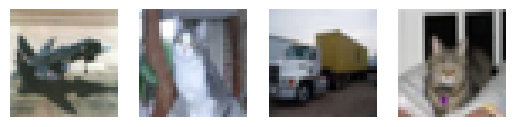

In [12]:
dm = ImageDataModule(ImageDataModuleConfig("cifar10_images", batch_size=4))
dm.setup()

batch, _ = next(iter(dm.train_dataloader()))
batch = batch.to(device=device, dtype=dtype)

plot_images(batch.float().cpu())

### Experiments

#### Sampling

0it [00:00, ?it/s]

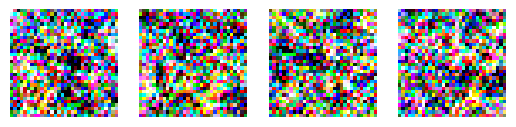

In [13]:
consistency_sampling_and_editing = ConsistencySamplingAndEditing()

with torch.no_grad():
    samples = consistency_sampling_and_editing(
        unet,
        torch.randn((4, 3, 32, 32), device=device, dtype=dtype),
        sigmas=[80.0],  # Use more steps for better samples e.g 2-5
        clip_denoised=True,
        verbose=True,
    )

plot_images(samples.float().cpu())

#### Inpainting

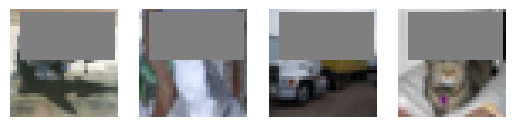

In [14]:
random_erasing = T.RandomErasing(p=1.0, scale=(0.2, 0.5), ratio=(0.5, 0.5))
masked_batch = random_erasing(batch)
mask = torch.logical_not(batch == masked_batch)

plot_images(masked_batch.float().cpu())

  0%|          | 0/1 [00:00<?, ?it/s]

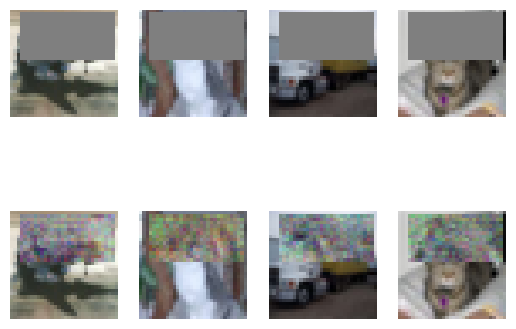

In [15]:
with torch.no_grad():
    inpainted_batch = consistency_sampling_and_editing(
        unet,
        masked_batch,
        sigmas=[5.23, 2.25],
        mask=mask.to(dtype=dtype),
        clip_denoised=True,
        verbose=True,
    )

plot_images(torch.cat((masked_batch, inpainted_batch), dim=0).float().cpu())

#### Interpolation

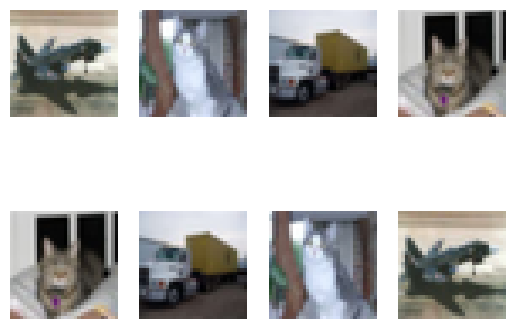

In [16]:
batch_a = batch.clone()
batch_b = torch.flip(batch, dims=(0,))

plot_images(torch.cat((batch_a, batch_b), dim=0).float().cpu())

  0%|          | 0/1 [00:00<?, ?it/s]

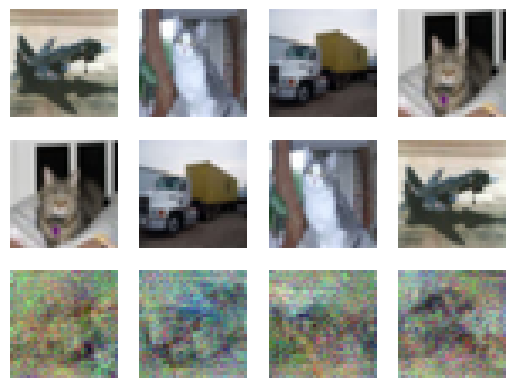

In [20]:
with torch.no_grad():
    interpolated_batch = consistency_sampling_and_editing.interpolate(
        unet,
        batch_a,
        batch_b,
        ab_ratio=0.5,
        sigmas=[5.23, 2.25],
        clip_denoised=True,
        verbose=True,
    )

plot_images(torch.cat((batch_a, batch_b, interpolated_batch), dim=0).float().cpu())

## Acknowledgment

This notebook on the Consistency Trajectory Model (CTM) is inspired by the work on the [Consistency Model (CM)](https://colab.research.google.com/github/Kinyugo/consistency_models/blob/main/notebooks/consistency_models_training_example.ipynb). 